# 8차시 정답 Notebook — 공정 이상과 원인 후보 찾기

## 1단계. 데이터 불러오기

In [1]:
import pandas as pd

df = pd.read_csv("../../data/weekly/week08/week08_anomaly_root_cause.csv")
df.head()

,측정시간,로트번호,설비번호,공정명,온도_섭씨,압력_Pa,진공도_mTorr,두께_nm,진동_mm_s,냉각수온도_섭씨,습도_pct,합격여부
0,2024-03-01 00:00,LOT-0404,EQ-02,식각,303.4,1017.3,4.92,104.66,0.682,19.52,47.4,1
1,2024-03-01 04:00,LOT-0094,EQ-04,증착,302.1,1016.5,5.12,100.03,0.472,20.90,50.4,1
2,2024-03-01 07:00,LOT-0408,EQ-02,증착,295.6,1018.4,5.24,98.62,0.636,19.00,45.7,-1
3,2024-03-01 22:00,LOT-0721,EQ-04,식각,298.4,1010.8,4.55,93.92,0.499,19.26,43.3,1
4,2024-03-02 08:00,LOT-0455,EQ-02,산화,300.1,1015.9,5.27,101.28,0.728,20.43,43.0,1


## 2단계. 진공도 정상 범위 이탈 데이터 찾기

In [2]:
vac_low, vac_high = 4.5, 5.5
vac_outlier = df[(df["진공도_mTorr"] < vac_low) | (df["진공도_mTorr"] > vac_high)]
print("진공도 이탈 행 수:", len(vac_outlier))

진공도 이탈 행 수: 78


## 3단계. 진공도 이탈 여부에 따른 불합격률 비교

In [3]:
df["불합격여부_숫자"] = (df["합격여부"] == -1).astype(int)

is_out = (df["진공도_mTorr"] < vac_low) | (df["진공도_mTorr"] > vac_high)
fail_in = df.loc[~is_out, "불합격여부_숫자"].mean() * 100
fail_out = df.loc[is_out, "불합격여부_숫자"].mean() * 100
print(f"정상 범위 안 불합격률: {fail_in:.2f}%")
print(f"정상 범위 밖 불합격률: {fail_out:.2f}%")

정상 범위 안 불합격률: 8.06%
정상 범위 밖 불합격률: 25.64%


**답**: 진공도 이탈은 불합격의 원인 후보로 볼 수 있다(실제 인과관계는 추가 검증 필요).

## 4단계. 온도와 두께의 관계

C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44760 (\N{HANGUL SYLLABLE GGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49453 (\N{HANGUL SYLL

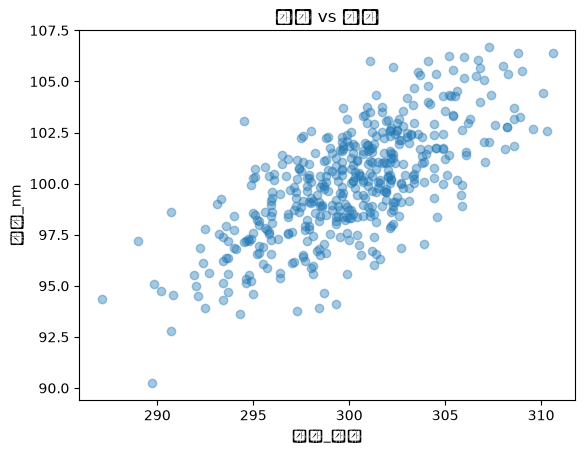

상관계수 r = 0.71


In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["온도_섭씨"], df["두께_nm"], alpha=0.4)
plt.xlabel("온도_섭씨"); plt.ylabel("두께_nm"); plt.title("온도 vs 두께")
plt.show()

r = df["온도_섭씨"].corr(df["두께_nm"])
print("상관계수 r =", round(r, 2))

## 5단계. 습도(대조군)와 불합격의 관계 확인하기

In [5]:
r_humid = df["습도_pct"].corr(df["불합격여부_숫자"])
print("습도-불합격 상관계수 r =", round(r_humid, 2))

습도-불합격 상관계수 r = -0.13


**답**: 습도의 상관계수는 0에 가까워 뚜렷한 관계가 없다. 이는 '관계가 없다'는 것도
정상적이고 의미 있는 분석 결과임을 보여준다(모든 변수가 불량과 관련 있는 것은 아니다).

## 6단계(도전). EQ-02의 진동 값 비교하기

In [6]:
df.groupby("설비번호")["진동_mm_s"].mean().round(3)

설비번호
EQ-01    0.507
EQ-02    0.678
EQ-03    0.503
EQ-04    0.501
Name: 진동_mm_s, dtype: float64

## 7단계. 오늘의 분석을 한 문장으로 정리하기

> 진공도가 정상 범위를 벗어나면 불합격률이 약 8.06%에서 25.64%로 높아지는 경향이 관찰되어,
> 진공도 이탈은 불합격의 원인 후보로 볼 수 있다. 다만 상관관계만으로 원인이라고 단정할 수 없으며,
> 정확한 원인 확인을 위해서는 추가 데이터와 실험이 필요하다.

## 8단계. AI에게 질문하며 더 알아보기
오늘 배운 상관관계·원인 후보 개념에 대해 AI 챗봇에게 질문해 이해를 넓혀봅니다.

질문 예시:
- "상관계수(r)가 0.7이면 '강한 상관관계'라고 할 수 있나요? 판단 기준이 있나요?"
- "상관관계와 인과관계는 정확히 어떻게 다른가요?"
- "'대조군(control group)'이라는 개념이 왜 중요한가요?"
- "여러 변수 중 어떤 변수가 불량과 가장 관련 있는지 한 번에 비교하려면 어떻게 하나요?"

## 9단계. AI에게 코드 생성 요청하고 직접 실행해보기
프롬프트 예시: "두 숫자 리스트의 상관계수를 계산하고, 절댓값이 0.5보다 크면 '뚜렷한 관계',
아니면 '약한 관계'라고 출력하는 코드를 만들어줘."

아래는 AI가 생성해줄 수 있는 예시 코드와 실행 결과입니다.

In [7]:
temp_sample = pd.Series([295.4, 298.1, 312.6, 301.0, 296.8, 305.2])
fail_sample = pd.Series([0, 0, 1, 0, 0, 1])

r = temp_sample.corr(fail_sample)
label = "뚜렷한 관계" if abs(r) > 0.5 else "약한 관계"
print(f"상관계수 r = {r:.2f} → {label}")

상관계수 r = 0.89 → 뚜렷한 관계


## 10단계. 연습문제 — 진동 값과 불합격의 관계 확인하기

In [8]:
r_vib = df["진동_mm_s"].corr(df["불합격여부_숫자"])
print("진동-불합격 상관계수 r =", round(r_vib, 2))

진동-불합격 상관계수 r = 0.02


## 11단계. AI로 재미있는 미니 프로그램 만들기 🎉 — 원인 후보 추리 게임
프롬프트 예시: "변수 이름과 상관계수가 담긴 딕셔너리를 받아서, 절댓값이 큰 순서로 정렬해
'용의선상 원인 후보 랭킹'처럼 🔎 이모지와 함께 출력하는 파이썬 코드를 만들어줘."

아래는 AI가 생성해줄 수 있는 예시 코드와 실행 결과입니다(9단계 예시 코드가 `r` 변수를
다른 값으로 재사용했으므로, 4단계의 온도-두께 상관계수를 `r_thickness`로 다시 계산해
사용합니다).

In [ ]:
r_thickness = df["온도_섭씨"].corr(df["두께_nm"])  # 9단계 예시 코드가 r 변수를 재사용했으므로 다시 계산
suspects = {"온도-두께": r_thickness, "습도-불합격": r_humid, "진동-불합격": r_vib}
ranked_suspects = sorted(suspects.items(), key=lambda item: abs(item[1]), reverse=True)

print("🔎 원인 후보 추리 게임 결과 🔎")
for rank, (name, value) in enumerate(ranked_suspects, start=1):
    print(f"{rank}위 원인 후보: {name} (상관계수 {value:.2f})")